# Menentukan Pertanyaan Bisnis

Dalam upaya memahami pola penggunaan layanan bike sharing, analisis ini difokuskan pada beberapa faktor utama yang diduga memengaruhi jumlah penyewaan sepeda. Oleh karena itu, dirumuskan pertanyaan bisnis sebagai berikut:

- Pertanyaan 1: Bagaimana variasi kondisi cuaca harian (weathersit) memengaruhi jumlah total penyewaan sepeda (cnt), dan sejauh mana perbedaan tersebut terlihat selama periode 2011–2012 untuk membantu pengambilan keputusan terkait pengelolaan operasional layanan?

- Pertanyaan 2: Bagaimana perbedaan pola penggunaan layanan bike sharing antara hari kerja (workingday) dan hari libur dalam periode 2011–2012, serta bagaimana informasi ini dapat dimanfaatkan untuk mengoptimalkan strategi distribusi dan ketersediaan sepeda?

# Import Libraries/Packages yang Digunakan

In [66]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

Data Wrangling adalah proses menyiapkan data mentah agar siap dianalisis.
Tahap ini sangat penting karena kualitas analisis sangat bergantung pada kualitas data.

Pada tahap ini, kita mengumpulkan dan memuat dataset ke dalam Python (DataFrame).

- `day.csv`: data penyewaan per hari
- `hour.csv`: data penyewaan per jam

Pada analisis ini, fokus utama menggunakan day_df

In [67]:
# Membaca dataset dari folder sample_data
day_df = pd.read_csv("/content/sample_data/day.csv")
hour_df = pd.read_csv("/content/sample_data/hour.csv")

# Menampilkan 5 baris pertama untuk memahami struktur data
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Assessing Data

Tahap ini bertujuan untuk mengevaluasi kualitas data dan menemukan masalah.


- `day_df.info()`: Melihat tipe data dan Mengetahui jumlah data

- `day_df.describe()`: Melihat distribusi data dan Mendeteksi nilai aneh (outlier)

Ditemukan beberapa isu, seperti tipe data yang belum sesuai pada kolom tanggal serta penggunaan kode numerik pada variabel kategori yang kurang informatif.


In [68]:
# Melihat informasi dataset
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [69]:
# Melihat statistik deskriptif untuk memahami distribusi data
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


## Cek missing Value


In [70]:
# Mengecek apakah ada missing value pada setiap kolom
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


## Cek Duplikat

In [71]:
# Mengecek apakah ada data duplikat
day_df.duplicated().sum()

np.int64(0)

## Cleaning Data

Untuk mengatasi permasalahan pada proses assessing data, dilakukan proses cleaning data dengan mengubah tipe data menjadi format datetime serta melakukan mapping nilai kategori menjadi label yang lebih mudah dipahami.


Dengan Mengubah Tipe Data Supaya bisa analisis berbasis waktu (trend, grouping)


`day_df['dteday'] = pd.to_datetime(day_df['dteday'])`


Hasil dari tahap ini adalah dataset yang lebih bersih, terstruktur, dan siap digunakan untuk proses analisis lebih lanjut.

In [72]:
# Mengubah tipe data kolom 'dteday' dari object menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


## Mapping Kategori

Mengubah Kategori Menjadi Label agar data lebih mudah dipahami dan lebih jelas saat visualisasi.

In [73]:

# Membuat mapping untuk mengubah kode numerik menjadi kategori yang lebih informatif
season_mapping = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_mapping = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow',
    4: 'Heavy Rain'
}

# Mengganti nilai numerik dengan label kategori
day_df['season'] = day_df['season'].map(season_mapping)
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)

# Menampilkan hasil setelah cleaning
day_df


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,Spring,1,12,0,4,1,Mist,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,Spring,1,12,0,5,1,Mist,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,Spring,1,12,0,6,0,Mist,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,Spring,1,12,0,0,0,Clear,0.255833,0.231700,0.483333,0.350754,364,1432,1796


# Exploratory Data Analysis (EDA)

## Pertanyaan 1:

Bagaimana variasi kondisi cuaca harian (weathersit) memengaruhi jumlah total penyewaan sepeda (cnt), dan sejauh mana perbedaan tersebut terlihat selama periode 2011–2012 untuk membantu pengambilan keputusan terkait pengelolaan operasional layanan?




Dari hasil analisis, terlihat bahwa kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda.

Cuaca cerah menunjukkan rata-rata penyewaan tertinggi, sementara kondisi cuaca yang lebih buruk seperti hujan atau salju menunjukkan penurunan jumlah penyewaan yang cukup drastis.

Hal ini menunjukkan bahwa pengguna cenderung menggunakan sepeda saat kondisi cuaca mendukung.

In [74]:
# Mengelompokkan data berdasarkan kondisi cuaca
day_df.groupby('weathersit')['cnt'].mean()

,cnt
weathersit,
Clear,4876.786177
Light Snow,1803.285714
Mist,4035.862348


## Pertanyaan 2:
Bagaimana perbedaan pola penggunaan layanan bike sharing antara hari kerja (workingday) dan hari libur dalam periode 2011–2012, serta bagaimana informasi ini dapat dimanfaatkan untuk mengoptimalkan strategi distribusi dan ketersediaan sepeda?


Hasil analisis menunjukkan bahwa jumlah penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur.

Hal ini mengindikasikan bahwa sepeda lebih banyak digunakan sebagai sarana transportasi harian, seperti untuk pergi bekerja atau sekolah, dibandingkan untuk keperluan rekreasi.

In [75]:
# Mengelompokkan data berdasarkan tipe hari (0 = libur, 1 = kerja)
day_df.groupby('workingday')['cnt'].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


## Tren waktu


Analisis tren menunjukkan adanya fluktuasi jumlah penyewaan dari waktu ke waktu. Pola ini dapat dipengaruhi oleh faktor musiman maupun kondisi eksternal seperti cuaca.

In [76]:
# Mengelompokkan data berdasarkan tipe hari (0 = libur, 1 = kerja)
trend = day_df.groupby('dteday')['cnt'].sum()
trend.head()

,cnt
dteday,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600


## Ringkasan EDA

Berdasarkan hasil eksplorasi data, ditemukan bahwa kondisi cuaca dan jenis hari (hari kerja atau hari libur) memiliki pengaruh terhadap jumlah penyewaan sepeda.

Cuaca yang baik cenderung meningkatkan jumlah penyewaan, sedangkan cuaca buruk menyebabkan penurunan penggunaan. Selain itu, hari kerja menunjukkan tingkat penyewaan yang lebih tinggi dibandingkan hari libur, yang mengindikasikan bahwa sepeda banyak digunakan sebagai alat transportasi harian.

# Visualization

Dalam pembuatan visualisasi, digunakan prinsip kejelasan dan kesederhanaan, dengan memilih jenis grafik yang sesuai untuk membandingkan kategori (bar chart) dan melihat tren (line chart).

Setiap visualisasi dilengkapi dengan judul, label sumbu, serta interpretasi untuk mempermudah pemahaman hasil analisis.



## 1. Pengaruh Cuaca terhadap Penyewaan

Grafik di bawah menunjukkan bahwa kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda.

Terlihat bahwa pada kondisi cuaca cerah, jumlah penyewaan mencapai nilai tertinggi. Sebaliknya, ketika kondisi cuaca memburuk seperti hujan atau salju, jumlah penyewaan mengalami penurunan yang cukup tajam.

Hal ini menunjukkan bahwa pengguna cenderung lebih aktif menggunakan layanan bike sharing saat kondisi cuaca mendukung.

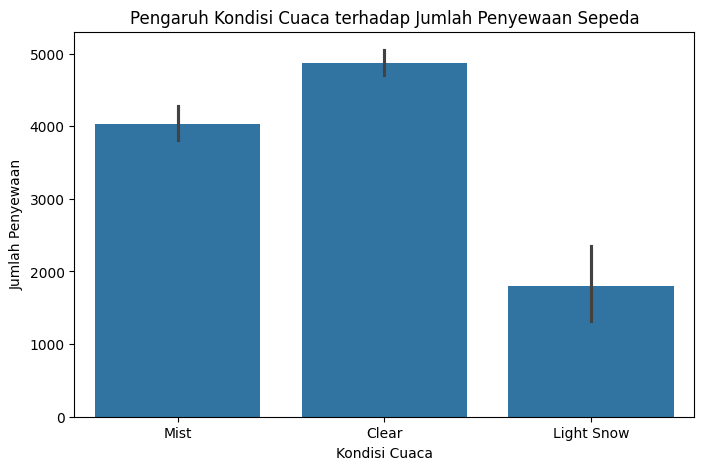

In [77]:
# Membuat grafik bar untuk melihat pengaruh cuaca terhadap jumlah penyewaan
plt.figure(figsize=(8,5))  # Mengatur ukuran grafik

# Membuat barplot
sns.barplot(x='weathersit', y='cnt', data=day_df)

# Menambahkan judul dan label
plt.title('Pengaruh Kondisi Cuaca terhadap Jumlah Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Penyewaan')

# Menampilkan grafik
plt.show()

## 2. Hari Kerja vs Hari Libur

Grafik menunjukkan bahwa jumlah penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur.

Hal ini mengindikasikan bahwa sepeda lebih banyak dimanfaatkan sebagai sarana transportasi harian, seperti untuk bekerja atau sekolah, dibandingkan untuk aktivitas rekreasi.

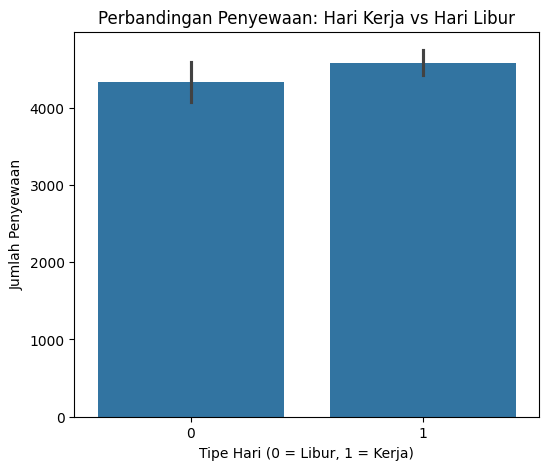

In [78]:
# Membuat grafik perbandingan antara hari kerja dan hari libur
plt.figure(figsize=(6,5))

# Membuat barplot
sns.barplot(x='workingday', y='cnt', data=day_df)


# Menambahkan judul dan label
plt.title('Perbandingan Penyewaan: Hari Kerja vs Hari Libur')
plt.xlabel('Tipe Hari (0 = Libur, 1 = Kerja)')
plt.ylabel('Jumlah Penyewaan')

# Menampilkan grafik
plt.show()

## 3. Tren Waktu

Grafik tren menunjukkan adanya fluktuasi jumlah penyewaan sepeda dari waktu ke waktu.

Pola ini kemungkinan dipengaruhi oleh faktor musiman serta kondisi eksternal seperti cuaca, yang memperkuat hasil analisis sebelumnya bahwa faktor lingkungan berperan penting dalam menentukan tingkat penggunaan layanan.


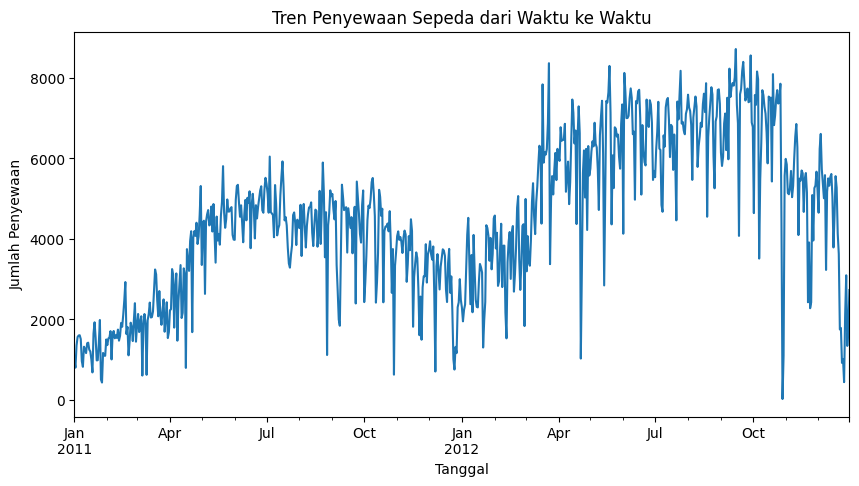

In [79]:
# Membuat grafik tren penyewaan dari waktu ke waktu
plt.figure(figsize=(10,5))

# Plot data tren
trend.plot()

# Menambahkan judul dan label
plt.title('Tren Penyewaan Sepeda dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')

# Menampilkan grafik
plt.show()

# Conclusion

### Kesimpulan 1: Pengaruh Cuaca terhadap Penyewaan

Berdasarkan hasil analisis dan visualisasi, dapat disimpulkan bahwa kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda.

Jumlah penyewaan tertinggi terjadi pada kondisi cuaca cerah, sementara pada kondisi cuaca yang kurang baik seperti hujan atau salju, jumlah penyewaan mengalami penurunan yang cukup drastis.

Hal ini menunjukkan bahwa pengguna cenderung lebih memilih menggunakan sepeda saat kondisi lingkungan mendukung.

### Kesimpulan 2: Hari Kerja vs Hari Libur

Hasil analisis menunjukkan bahwa jumlah penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur.

Hal ini mengindikasikan bahwa layanan bike sharing lebih banyak digunakan sebagai sarana transportasi harian dibandingkan untuk kebutuhan rekreasi. Pola ini mencerminkan bahwa pengguna memanfaatkan sepeda untuk aktivitas rutin seperti bekerja atau sekolah.

# Recommendation

Berdasarkan hasil analisis yang telah dilakukan, terdapat beberapa rekomendasi yang dapat dipertimbangkan:

1. Mengoptimalkan jumlah sepeda yang tersedia pada kondisi cuaca cerah, karena permintaan cenderung meningkat secara signifikan.

2. Mengurangi atau menyesuaikan operasional pada kondisi cuaca buruk untuk meningkatkan efisiensi penggunaan sumber daya.

3. Menyediakan program promosi atau diskon pada hari libur untuk meningkatkan minat penggunaan sepeda di luar hari kerja.

4. Mengembangkan strategi layanan berbasis pola penggunaan, seperti menambah titik penyewaan di area perkantoran untuk mendukung kebutuhan pengguna pada hari kerja.

Secara keseluruhan, analisis ini menunjukkan bahwa faktor eksternal seperti cuaca serta jenis hari memiliki peran penting dalam memengaruhi pola penggunaan layanan bike sharing. Oleh karena itu, pemanfaatan data secara optimal dapat membantu dalam pengambilan keputusan yang lebih efektif dan berbasis data.

## Menyimpan Data

In [80]:
# Menyimpan dataset yang sudah dibersihkan ke dalam file CSV
day_df.to_csv('sample_data/main_data.csv', index=False)
